# Praktikum 1 — Minggu 3: Akuisisi Data dari API Publik dan Web Scraping/Crawling

**Mata Kuliah:** Data Analitik
**Sub-CPMK-03:** Mampu melakukan akuisisi data dari berbagai sumber serta membersihkan dan mentransformasinya menjadi dataset analitik yang berkualitas.

Notebook ini berisi seluruh kode praktikum: Bagian A (API), Bagian B (Web Scraping/Crawling), Bagian C (Inspeksi Data), dan Bagian D (Visualisasi by Code & by Tools). Jalankan sel secara berurutan dari atas ke bawah.

## Persiapan: instal pustaka yang dibutuhkan

In [2]:
!pip install requests beautifulsoup4 lxml pandas matplotlib -q

## Bagian A — Akuisisi Data dari API Publik (Open-Meteo)

Data cuaca kota-kota di sekitar Danau Toba, tanpa API key.

In [3]:
"""
Praktikum 1 - Minggu 3 - Bagian A
Akuisisi Data dari API Publik (Open-Meteo)
Data cuaca kota-kota di sekitar Danau Toba

Mata Kuliah: Data Analitik
Sub-CPMK-03: akuisisi, pembersihan, dan transformasi data dari berbagai sumber
"""
import requests
import pandas as pd
import json
import os
from datetime import datetime

os.makedirs("data_raw", exist_ok=True)

# Titik koordinat kota-kota di sekitar Danau Toba
KOTA = {
    "Balige":          {"lat": 2.3333, "lon": 99.0667},
    "Pematangsiantar": {"lat": 2.9595, "lon": 99.0687},
    "Medan":           {"lat": 3.5952, "lon": 98.6722},
}

BASE_URL = "https://api.open-meteo.com/v1/forecast"


def ambil_data_cuaca(lat, lon):
    params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": "temperature_2m,relative_humidity_2m,precipitation",
        "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
        "timezone": "auto",     # otomatis memakai zona waktu lokasi
        "forecast_days": 3
    }
    response = requests.get(BASE_URL, params=params, timeout=15)
    response.raise_for_status()   # hentikan proses jika status bukan 200
    return response.json()


def main():
    # --- A2: Request data untuk tiap kota ---
    semua_respon = {}
    for kota, koordinat in KOTA.items():
        print(f"Mengambil data cuaca: {kota} ...")
        try:
            semua_respon[kota] = ambil_data_cuaca(koordinat["lat"], koordinat["lon"])
        except requests.exceptions.RequestException as e:
            print(f"  Gagal mengambil data {kota}: {e}")

    # --- A3: Simpan JSON mentah apa adanya (arsip data mentah, sebelum diubah bentuk apa pun) ---
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")
    json_path = f"data_raw/cuaca_api_mentah_{timestamp}.json"
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(semua_respon, f, ensure_ascii=False, indent=2)
    print(f"JSON mentah tersimpan: {json_path}")

    # --- A4: Ratakan JSON bersarang (per kota -> per jam) menjadi tabel ---
    daftar_baris = []
    for kota, data in semua_respon.items():
        jam = data["hourly"]["time"]
        suhu = data["hourly"]["temperature_2m"]
        kelembapan = data["hourly"]["relative_humidity_2m"]
        hujan = data["hourly"]["precipitation"]
        for i in range(len(jam)):
            daftar_baris.append({
                "kota": kota,
                "waktu": jam[i],
                "suhu_c": suhu[i],
                "kelembapan_persen": kelembapan[i],
                "presipitasi_mm": hujan[i]
            })

    df_cuaca = pd.DataFrame(daftar_baris)
    print(df_cuaca.head())
    print("Jumlah baris:", len(df_cuaca))

    # --- A5: Simpan sebagai CSV mentah ---
    df_cuaca.to_csv("data_raw/cuaca_api_mentah.csv", index=False)
    print("CSV mentah tersimpan: data_raw/cuaca_api_mentah.csv")


if __name__ == "__main__":
    main()


Mengambil data cuaca: Balige ...
Mengambil data cuaca: Pematangsiantar ...
Mengambil data cuaca: Medan ...
JSON mentah tersimpan: data_raw/cuaca_api_mentah_20260917_1339.json
     kota             waktu  suhu_c  kelembapan_persen  presipitasi_mm
0  Balige  2026-09-17T00:00    22.5                 81             0.0
1  Balige  2026-09-17T01:00    22.2                 85             0.0
2  Balige  2026-09-17T02:00    21.8                 83             0.0
3  Balige  2026-09-17T03:00    21.5                 85             0.0
4  Balige  2026-09-17T04:00    21.3                 86             0.1
Jumlah baris: 216
CSV mentah tersimpan: data_raw/cuaca_api_mentah.csv


## Bagian B — Akuisisi Data via Web Scraping/Crawling (Books to Scrape)

Situs sandbox resmi untuk latihan scraping.

In [4]:
"""
Praktikum 1 - Minggu 3 - Bagian B
Akuisisi Data via Web Scraping/Crawling (books.toscrape.com)

Mata Kuliah: Data Analitik
Sub-CPMK-03: akuisisi, pembersihan, dan transformasi data dari berbagai sumber

Catatan etika: books.toscrape.com adalah situs sandbox resmi yang memang
dibuat untuk latihan scraping. Untuk situs lain, SELALU periksa robots.txt
dan Terms of Service sebelum melakukan scraping/crawling.
"""
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import os

os.makedirs("data_raw", exist_ok=True)

BASE_URL = "https://books.toscrape.com/catalogue/page-{}.html"
HEADERS = {"User-Agent": "MahasiswaDataAnalitik-ITDel/1.0 (tugas praktikum)"}


def ambil_satu_halaman(nomor_halaman):
    url = BASE_URL.format(nomor_halaman)
    response = requests.get(url, headers=HEADERS, timeout=15)
    if response.status_code != 200:
        return None
    return response.text


def ekstrak_buku(html):
    soup = BeautifulSoup(html, "lxml")
    hasil = []
    for produk in soup.select("article.product_pod"):
        judul_tag = produk.select_one("h3 a")
        judul = judul_tag["title"] if judul_tag else None

        harga_tag = produk.select_one("p.price_color")
        harga_mentah = harga_tag.get_text(strip=True) if harga_tag else None

        rating_tag = produk.select_one("p.star-rating")
        kelas_rating = rating_tag["class"] if rating_tag else []
        rating_mentah = next((k for k in kelas_rating if k != "star-rating"), None)

        ketersediaan_tag = produk.select_one("p.instock.availability")
        ketersediaan_mentah = ketersediaan_tag.get_text(strip=True) if ketersediaan_tag else None

        hasil.append({
            "judul": judul,
            "harga_mentah": harga_mentah,               # masih string, contoh "£51.77"
            "rating_mentah": rating_mentah,              # masih teks: "One".."Five"
            "ketersediaan_mentah": ketersediaan_mentah   # masih kalimat, contoh "In stock"
        })
    return hasil


def crawl_beberapa_halaman(jumlah_halaman=5, jeda_detik=1):
    """Crawling sopan: batasi jumlah halaman dan beri jeda antar-request."""
    semua_buku = []
    for halaman in range(1, jumlah_halaman + 1):
        print(f"Mengambil halaman {halaman} ...")
        html = ambil_satu_halaman(halaman)
        if html is None:
            print(f"  Halaman {halaman} tidak tersedia, berhenti crawling.")
            break
        semua_buku.extend(ekstrak_buku(html))
        time.sleep(jeda_detik)   # jeda sopan agar tidak membebani server
    return semua_buku


def main():
    data_buku = crawl_beberapa_halaman(jumlah_halaman=5, jeda_detik=1)
    df_buku = pd.DataFrame(data_buku)
    print(df_buku.head())
    print("Jumlah baris:", len(df_buku))

    df_buku.to_csv("data_raw/buku_scraping_mentah.csv", index=False)
    print("CSV mentah tersimpan: data_raw/buku_scraping_mentah.csv")


if __name__ == "__main__":
    main()


Mengambil halaman 1 ...
Mengambil halaman 2 ...
Mengambil halaman 3 ...
Mengambil halaman 4 ...
Mengambil halaman 5 ...
                                   judul harga_mentah rating_mentah  \
0                   A Light in the Attic      Â£51.77         Three   
1                     Tipping the Velvet      Â£53.74           One   
2                             Soumission      Â£50.10           One   
3                          Sharp Objects      Â£47.82          Four   
4  Sapiens: A Brief History of Humankind      Â£54.23          Five   

  ketersediaan_mentah  
0            In stock  
1            In stock  
2            In stock  
3            In stock  
4            In stock  
Jumlah baris: 100
CSV mentah tersimpan: data_raw/buku_scraping_mentah.csv


## Bagian C — Inspeksi Awal Kualitas Data + Data Preparation Log

In [5]:
"""
Praktikum 1 - Minggu 3 - Bagian C
Inspeksi Awal Kualitas Data + Data Preparation Log

Mata Kuliah: Data Analitik
Sub-CPMK-03: akuisisi, pembersihan, dan transformasi data dari berbagai sumber

Jalankan setelah akuisisi_api.py dan akuisisi_scraping.py berhasil dijalankan
(membutuhkan data_raw/cuaca_api_mentah.csv dan data_raw/buku_scraping_mentah.csv).
"""
import pandas as pd


def inspeksi(nama, df):
    print(f"\n=== {nama} ===")
    print("Ukuran:", df.shape)
    print(df.info())
    print("\nMissing value per kolom:")
    print(df.isnull().sum())
    print("\nJumlah baris duplikat:", df.duplicated().sum())


def main():
    df_cuaca = pd.read_csv("data_raw/cuaca_api_mentah.csv")
    df_buku = pd.read_csv("data_raw/buku_scraping_mentah.csv")

    inspeksi("Data Cuaca (API)", df_cuaca)
    inspeksi("Data Buku (Scraping)", df_buku)

    # Isu format spesifik yang perlu dicatat manual
    print("\nContoh isu format - harga (masih string bersimbol mata uang):")
    print(df_buku["harga_mentah"].head())

    print("\nContoh isu format - rating (masih teks, bukan angka):")
    print(df_buku["rating_mentah"].unique())

    # --- Susun Data Preparation Log ---
    log = pd.DataFrame([
        {
            "sumber": "Open-Meteo API",
            "format_asal": "JSON (bersarang per jam)",
            "jumlah_baris": len(df_cuaca),
            "jumlah_kolom": df_cuaca.shape[1],
            "missing_value_ditemukan": int(df_cuaca.isnull().sum().sum()),
            "duplikat_ditemukan": int(df_cuaca.duplicated().sum()),
            "isu_format_ditemukan": "nama kolom mencampur nilai & satuan (suhu_c, kelembapan_persen)",
            "rencana_penanganan": "pisahkan nilai dan satuan pada Praktikum 2"
        },
        {
            "sumber": "Books to Scrape (scraping)",
            "format_asal": "HTML",
            "jumlah_baris": len(df_buku),
            "jumlah_kolom": df_buku.shape[1],
            "missing_value_ditemukan": int(df_buku.isnull().sum().sum()),
            "duplikat_ditemukan": int(df_buku.duplicated().sum()),
            "isu_format_ditemukan": "harga bersimbol mata uang (string), rating berupa kata, ketersediaan berupa kalimat",
            "rencana_penanganan": "parsing harga ke angka, mapping rating ke angka, ketersediaan ke boolean pada Praktikum 2"
        }
    ])

    log.to_csv("data_preparation_log.csv", index=False)
    print("\nData Preparation Log tersimpan: data_preparation_log.csv")
    print(log)


if __name__ == "__main__":
    main()



=== Data Cuaca (API) ===
Ukuran: (216, 5)
<class 'pandas.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   kota               216 non-null    str    
 1   waktu              216 non-null    str    
 2   suhu_c             216 non-null    float64
 3   kelembapan_persen  216 non-null    int64  
 4   presipitasi_mm     216 non-null    float64
dtypes: float64(2), int64(1), str(2)
memory usage: 8.6 KB
None

Missing value per kolom:
kota                 0
waktu                0
suhu_c               0
kelembapan_persen    0
presipitasi_mm       0
dtype: int64

Jumlah baris duplikat: 0

=== Data Buku (Scraping) ===
Ukuran: (100, 4)
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   judul                100 non-null    str  
 1

## Bagian D1 — Visualisasi By Code (Python/matplotlib)

Untuk visualisasi **By Tools (Tableau)**, ikuti langkah manual di modul (drag-and-drop di Tableau Desktop/Public) menggunakan file `data_raw/cuaca_api_mentah.csv` dan `data_raw/buku_scraping_mentah.csv` yang dihasilkan di atas.

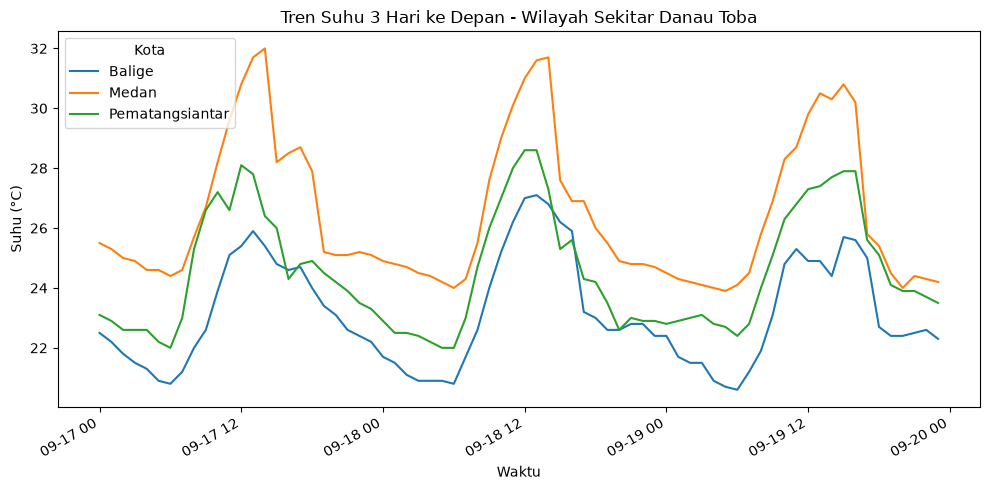

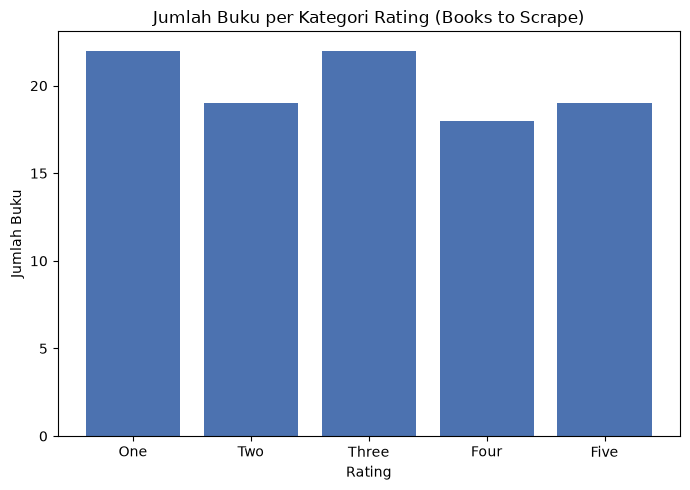

In [6]:
"""
Praktikum 1 - Minggu 3 - Bagian D1
Visualisasi Awal Dataset dengan Python (By Code)
"""
import pandas as pd
import matplotlib.pyplot as plt

df_cuaca = pd.read_csv("data_raw/cuaca_api_mentah.csv")
df_buku = pd.read_csv("data_raw/buku_scraping_mentah.csv")

# --- Visualisasi 1: Tren suhu per jam, dibedakan per kota ---
df_cuaca["waktu"] = pd.to_datetime(df_cuaca["waktu"])

fig, ax = plt.subplots(figsize=(10, 5))
for kota, grup in df_cuaca.groupby("kota"):
    grup = grup.sort_values("waktu")
    ax.plot(grup["waktu"], grup["suhu_c"], label=kota)

ax.set_title("Tren Suhu 3 Hari ke Depan - Wilayah Sekitar Danau Toba")
ax.set_xlabel("Waktu")
ax.set_ylabel("Suhu (\u00b0C)")
ax.legend(title="Kota")
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("data_raw/viz_tren_suhu.png", dpi=150)
plt.show()

# --- Visualisasi 2: Jumlah buku per kategori rating ---
urutan_rating = ["One", "Two", "Three", "Four", "Five"]
jumlah_per_rating = (
    df_buku["rating_mentah"]
    .value_counts()
    .reindex(urutan_rating)
    .fillna(0)
)

fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.bar(jumlah_per_rating.index, jumlah_per_rating.values, color="#4C72B0")
ax2.set_title("Jumlah Buku per Kategori Rating (Books to Scrape)")
ax2.set_xlabel("Rating")
ax2.set_ylabel("Jumlah Buku")
plt.tight_layout()
plt.savefig("data_raw/viz_rating_buku.png", dpi=150)
plt.show()
